# LSTM / RNN OVERALL TRAINING NOTEBOOK

F1Tenth, Team 4 Final Project.

### Overview

This notebook is meant to be a baseline start for training and testing LSTM and RNN models with reference to MCP baselines.

It is split into relevant sections, and is meant to be highly modular allowing for changes to training data, model types, and methods.

## Section 0: Setup

Sets general parameters for the model, and sets the prediction length and batch size!

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import numpy as np
import pandas as pd
import random
import time
import json
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
# Feature selection
INPUT_FEATURES = ['velocity', 'steering_angle', 'lidar_scans']
TARGET_FEATURES = ['steering_angle', 'velocity']

# Sequence / batch settings
#Currently only predict a single timestamp, PREDICT_LENGTH is how far ahead we want to predict
#In traing data, each step is 10ms. So predict length 5 is 50ms into the future, could be tuned based on expected latency 
SEQ_LENGTH = 100       # How many past timesteps the model sees
PREDICT_LENGTH = 1    # How many timesteps into the future to predict
BATCH_SIZE = 64

# Choose split mode:
# - "episode": Random 70/15/15 split across all episodes (allows same map in train/val/test)
# - "map":     Split by unique maps/races 70/15/15, ensuring test set sees unseen maps
SPLIT_MODE = "map"  # Change to "map" for cross-map generalization testing

# -----------------------------
# Centralized tuning parameters
# -----------------------------
# Model setup parameters
MODEL_TYPE = 'LSTM'
RNN_HIDDEN_DIM = 64
NUM_RNN_LAYERS = 1
USE_EMBEDDING = True
EMBEDDING_DIM = 30
FC_LAYER_SIZES = [64, 32, 16]
DROPOUT = 0.2

# Training hyperparameters
EPOCHS = 5
LEARNING_RATE = 1e-3        # Slightly lower LR for stable sequence training
WEIGHT_DECAY = 1e-5
MAX_GRAD_NORM = 1.0
TEACHER_FORCING_RATIO = 1.0
EARLY_STOPPING_PATIENCE = 4
SCHEDULER_STEP_SIZE = 3
SCHEDULER_GAMMA = 0.5
STEERING_LOSS_WEIGHT = 1.0
VELOCITY_LOSS_WEIGHT = 1.0

# Save / experiment names
SAVE_MODEL_NAME = "LSTM_1B_64D_Pred1_Emb_ReLU"
NUM_EPOCHS = 20

# Device setup for GPU acceleration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(DEVICE)
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

cuda


## Section 1: Dataset Loading and Cleaning

Load dataset from pkl file.

Needs to be compatible with the trainer and usable with CUDA. 

Load from pkl and make the train test split based on episode. 
70% train
15% val
15% test

Split gt predicted labels and input sequence

masks sequences as required in order to make input based on only past and present information



In [ ]:
## Dataset loading and preparation based on episode-level PKL
# This assumes you have created `multimap_lstm_sequences_no_collisions.pkl`
# using the dataset_creation notebook.

import pickle

class EpisodeWindowDataset(Dataset):
    """Episode-based Dataset that yields fixed-length windows.

    Each item is a (inputs_window, target_timestep) pair drawn from a single episode.
    Episodes are never crossed when building windows.
    """

    def __init__(self, episodes, seq_length, predict_length, transform=None):
        self.episodes = episodes
        self.seq_length = seq_length
        self.predict_length = predict_length
        self.transform = transform

        # Precompute (episode_index, start_index) pairs for all valid windows
        self.index = []
        for ep_idx, ep in enumerate(self.episodes):
            T = ep["inputs"].shape[0]
            max_start = T - seq_length - predict_length + 1
            if max_start <= 0:
                continue
            for start in range(max_start):
                self.index.append((ep_idx, start))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        ep_idx, start = self.index[idx]
        ep = self.episodes[ep_idx]

        # Input window
        x = ep["inputs"][start : start + self.seq_length]

        # Target at the prediction horizon
        target_idx = start + self.seq_length + self.predict_length - 1
        y = ep["targets"][target_idx]

        x_tensor = torch.tensor(x, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        
        # Apply optional augmentation (only for training inputs)
        if self.transform is not None:
            x_tensor = self.transform(x_tensor)

        return x_tensor, y_tensor


def load_and_prep_data(pkl_path, seq_length, predict_length, batch_size, split_mode="episode", train_transform=None):
    """Load episode-level PKL, split by episodes or maps, normalize inputs/targets, and create DataLoaders.

    Args:
        pkl_path: Path to the episode PKL file.
        seq_length: Number of past timesteps the model sees.
        predict_length: Number of timesteps into the future to predict.
        batch_size: Batch size for DataLoaders.
        split_mode: Either "episode" (70/15/15 random split by episodes) or "map" (70/15/15 split by unique maps/races).
                   "map" mode ensures that different races are used for train/val/test, testing generalization to unseen maps.
        train_transform: Optional torch.nn.Module for data augmentation (only applied to training data).

    Returns:
        train_loader, val_loader, test_loader, test_episodes, input_scaler, target_scaler
    """
    # Load list of episode dicts
    with open(pkl_path, "rb") as f:
        episodes = pickle.load(f)

    # Filter to collision-free episodes if the flag is present
    episodes = [ep for ep in episodes if not ep.get("has_collision", False)]

    # Require minimum length to support at least one window
    min_len = seq_length + predict_length
    episodes = [ep for ep in episodes if ep["inputs"].shape[0] >= min_len]

    if not episodes:
        raise ValueError("No episodes available after filtering for length and collisions.")

    # ========== SPLITTING LOGIC ==========
    if split_mode == "map":
        # Split by unique maps/races
        unique_maps = sorted(list(set(ep.get("map", "unknown") for ep in episodes)))
        print(f"Unique maps found: {unique_maps}")

        # Shuffle maps and split 70/15/15
        random.shuffle(unique_maps)
        n_maps = len(unique_maps)
        n_train_maps = int(0.7 * n_maps)
        n_val_maps = int(0.15 * n_maps)

        train_maps = set(unique_maps[:n_train_maps])
        val_maps = set(unique_maps[n_train_maps : n_train_maps + n_val_maps])
        test_maps = set(unique_maps[n_train_maps + n_val_maps :])

        print(f"Train maps ({len(train_maps)}): {sorted(train_maps)}")
        print(f"Val maps ({len(val_maps)}): {sorted(val_maps)}")
        print(f"Test maps ({len(test_maps)}): {sorted(test_maps)}")

        # Partition episodes by their map
        train_episodes = [ep for ep in episodes if ep.get("map", "unknown") in train_maps]
        val_episodes = [ep for ep in episodes if ep.get("map", "unknown") in val_maps]
        test_episodes = [ep for ep in episodes if ep.get("map", "unknown") in test_maps]

        print(f"Total episodes: {len(episodes)} | train={len(train_episodes)}, val={len(val_episodes)}, test={len(test_episodes)}")

    elif split_mode == "episode":
        # Random 70/15/15 split by individual episodes (original behavior)
        episode_indices = list(range(len(episodes)))
        random.shuffle(episode_indices)
        episodes = [episodes[i] for i in episode_indices]

        n = len(episodes)
        n_train = int(0.7 * n)
        n_val = int(0.15 * n)

        train_episodes = episodes[:n_train]
        val_episodes = episodes[n_train : n_train + n_val]
        test_episodes = episodes[n_train + n_val :]

        print(f"Total episodes: {n} | train={len(train_episodes)}, val={len(val_episodes)}, test={len(test_episodes)}")

    else:
        raise ValueError(f"split_mode must be 'episode' or 'map', got '{split_mode}'.")

    # Fit scalers on train split only
    train_inputs_flat = np.concatenate([ep["inputs"] for ep in train_episodes], axis=0)
    train_targets_flat = np.concatenate([ep["targets"] for ep in train_episodes], axis=0)

    input_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    input_scaler.fit(train_inputs_flat)
    target_scaler.fit(train_targets_flat)

    def apply_scalers(ep_list):
        for ep in ep_list:
            ep["inputs"] = input_scaler.transform(ep["inputs"])
            ep["targets"] = target_scaler.transform(ep["targets"])
        return ep_list

    train_episodes = apply_scalers(train_episodes)
    val_episodes = apply_scalers(val_episodes)
    test_episodes = apply_scalers(test_episodes)

    # Build Datasets and DataLoaders
    train_dataset = EpisodeWindowDataset(train_episodes, seq_length, predict_length, transform=train_transform)
    val_dataset = EpisodeWindowDataset(val_episodes, seq_length, predict_length, transform=None)
    test_dataset = EpisodeWindowDataset(test_episodes, seq_length, predict_length, transform=None)

    print(f"Train windows: {len(train_dataset)}, Val windows: {len(val_dataset)}, Test windows: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, test_episodes, input_scaler, target_scaler


In [ ]:
# Load dataset from episode-level PKL and build DataLoaders

# Path is relative to this notebook (located in notebooks/)
candidate_paths = [
    os.path.join(os.getcwd(), "..", "pkl_datasets", "multimap_lstm_sequences_no_collisions.pkl"),
    os.path.join(os.getcwd(), "..", "datasets", "multimap_lstm_sequences_no_collisions.pkl"),  # Backward-compat fallback
]

PKL_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if PKL_PATH is None:
    raise FileNotFoundError(
        "Could not find multimap_lstm_sequences_no_collisions.pkl in ../pkl_datasets or ../datasets."
    )

print(f"Loading episodes from: {PKL_PATH}")

# Optional: Enable LiDAR augmentation (Gaussian noise + dropout)
ENABLE_LIDAR_AUGMENTATION = True
if ENABLE_LIDAR_AUGMENTATION:
    import sys
    sys.path.insert(0, os.path.join(os.getcwd(), ".."))
    from data_transforms import LiDARNoise
    train_augment = LiDARNoise(gaussian_sigma_m=0.1, dropout_prob=0.05)
    print(f"Training augmentation enabled: {train_augment}")
else:
    train_augment = None

train_loader, val_loader, test_loader, test_episodes, fitted_input_scaler, fitted_target_scaler = load_and_prep_data(
    pkl_path=PKL_PATH,
    seq_length=SEQ_LENGTH,
    predict_length=PREDICT_LENGTH,
    batch_size=BATCH_SIZE,
    split_mode=SPLIT_MODE,
    train_transform=train_augment,
)

print("DataLoaders ready for training.")

Loading episodes from: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../pkl_datasets/multimap_lstm_sequences_no_collisions.pkl
Unique maps found: ['Budapest_normal', 'Budapest_reverse', 'Melbourne_normal', 'Melbourne_reverse', 'Montreal_normal', 'Montreal_reverse', 'Monza_normal', 'Monza_reverse', 'Silverstone_normal', 'Silverstone_reverse', 'Spa_normal', 'Spa_reverse', 'Spielberg_normal', 'Spielberg_reverse']
Train maps (9): ['Budapest_normal', 'Melbourne_reverse', 'Montreal_normal', 'Montreal_reverse', 'Monza_normal', 'Monza_reverse', 'Silverstone_normal', 'Silverstone_reverse', 'Spielberg_normal']
Val maps (2): ['Spa_normal', 'Spa_reverse']
Test maps (3): ['Budapest_reverse', 'Melbourne_normal', 'Spielberg_reverse']
Total episodes: 131 | train=81, val=20, test=30
Train windows: 811520, Val windows: 279355, Test windows: 308339
DataLoaders ready for training.


In [73]:
def analyze_dataset_splits(pkl_path, seq_length, predict_length):
    """
    Analyze the dataset before loading for splitting.
    Shows available maps and episode counts per map.
    Useful for deciding which split_mode to use.
    """
    with open(pkl_path, "rb") as f:
        episodes = pickle.load(f)
    
    episodes = [ep for ep in episodes if not ep.get("has_collision", False)]
    min_len = seq_length + predict_length
    episodes = [ep for ep in episodes if ep["inputs"].shape[0] >= min_len]
    
    map_episodes = {}
    for ep in episodes:
        map_name = ep.get("map", "unknown")
        if map_name not in map_episodes:
            map_episodes[map_name] = []
        map_episodes[map_name].append(ep)
    
    print(f"\n=== Dataset Analysis ===")
    print(f"Total episodes (after filtering): {len(episodes)}")
    print(f"Unique maps: {len(map_episodes)}\n")
    
    for map_name in sorted(map_episodes.keys()):
        eps = map_episodes[map_name]
        print(f"  {map_name}: {len(eps)} episodes")
    
    return map_episodes

# Uncomment to analyze dataset structure before loading:
map_episodes = analyze_dataset_splits(PKL_PATH, SEQ_LENGTH, PREDICT_LENGTH)



=== Dataset Analysis ===
Total episodes (after filtering): 131
Unique maps: 14

  Budapest_normal: 10 episodes
  Budapest_reverse: 10 episodes
  Melbourne_normal: 10 episodes
  Melbourne_reverse: 10 episodes
  Montreal_normal: 10 episodes
  Montreal_reverse: 10 episodes
  Monza_normal: 10 episodes
  Monza_reverse: 1 episodes
  Silverstone_normal: 10 episodes
  Silverstone_reverse: 10 episodes
  Spa_normal: 10 episodes
  Spa_reverse: 10 episodes
  Spielberg_normal: 10 episodes
  Spielberg_reverse: 10 episodes


## Section 2: Model Setup

The main focus of this project is LSTMs. To train these effectively there have been a number of different appraoches to improve LSTM training. Also, since we are using Pytorch, we can easily test other models like RNNs or GRUs if time allows

Main points to Consider

1. Type of model: RNN, LSTM, GRU

2. Number of model blocks: Generally between 1 and 3 in past studies

3. Size of hidden state size for model

4. Embedding layer before input? Can reduce input dimensionilty and "weight" each input to allow the LSTM to make better choices

5. Size and number of FC layers after LSTM

6. Option to load existing model from huggingface or .pkl file

Good hyperparameter options/ideas

https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10275226




In [74]:

class F1TenthSequenceModel(nn.Module):
    def __init__(
        self,
        input_dim,
        rnn_hidden_dim,
        output_dim,
        model_type='LSTM',
        num_rnn_layers=2,
        use_embedding=True,
        embedding_dim=500,
        fc_layer_sizes=[256, 128, 32],
        dropout=0.2
    ):
        super(F1TenthSequenceModel, self).__init__()

        self.model_type = model_type.upper()
        self.use_embedding = use_embedding

        # Configure the Embedding Block (Dense / MLP style as per the paper)
        if self.use_embedding:
            self.embedding = nn.Sequential(
                nn.Linear(input_dim, embedding_dim),
                nn.ReLU()
            )
            rnn_input_dim = embedding_dim
        else:
            self.embedding = None
            rnn_input_dim = input_dim

        # Configure the Recurrent Core
        if self.model_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=rnn_input_dim, hidden_size=rnn_hidden_dim, num_layers=num_rnn_layers, batch_first=True, dropout=dropout if num_rnn_layers > 1 else 0)
        elif self.model_type == 'GRU':
            self.rnn = nn.GRU(input_size=rnn_input_dim, hidden_size=rnn_hidden_dim, num_layers=num_rnn_layers, batch_first=True, dropout=dropout if num_rnn_layers > 1 else 0)
        else:
            self.rnn = nn.RNN(input_size=rnn_input_dim, hidden_size=rnn_hidden_dim, num_layers=num_rnn_layers, batch_first=True, dropout=dropout if num_rnn_layers > 1 else 0)

        # Dynamically build the Fully Connected output block
        fc_modules = []
        current_input_size = rnn_hidden_dim

        for hidden_size in fc_layer_sizes:
            fc_modules.append(nn.Linear(current_input_size, hidden_size))
            fc_modules.append(nn.ReLU())
            current_input_size = hidden_size

        # Add the final output layer (the paper uses tanh for the final output)
        fc_modules.append(nn.Linear(current_input_size, output_dim))
        # fc_modules.append(nn.Tanh()) # REMOVED: Tanh limits output to [-1, 1], our targets are unscaled.

        self.fc = nn.Sequential(*fc_modules)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        # Pass through embedding if enabled
        if self.use_embedding:
            # Reshape to process all sequence steps through the linear layer efficiently
            x_reshaped = x.view(batch_size * seq_len, -1)
            embedded = self.embedding(x_reshaped)
            # Reshape back to sequence format for the RNN
            rnn_in = embedded.view(batch_size, seq_len, -1)
        else:
            rnn_in = x

        # Process through the selected RNN type
        if self.model_type == 'LSTM':
            rnn_out, (hidden, cell) = self.rnn(rnn_in)
        else:
            rnn_out, hidden = self.rnn(rnn_in)

        # Isolate the final timestep for prediction
        final_timestep_out = rnn_out[:, -1, :]
        predictions = self.fc(final_timestep_out)

        return predictions

def load_existing_model(model, filepath, device):
    """Loads weights from a .pkl or .pth file if it exists."""
    if os.path.exists(filepath):
        model.load_state_dict(torch.load(filepath, map_location=device))
        print(f"Successfully loaded model weights from {filepath}")
    else:
        print("File not found. Starting with randomly initialized weights.")
    return model



In [75]:
# TODO: Need to check input dimensions.
# The input is high-dimensional (LiDAR + kinematics), so we keep a reasonably
# expressive recurrent core and FC head.
input_dim = next(iter(train_loader))[0].shape[-1]

MODEL_CONFIG = {
    "input_dim": input_dim,
    "rnn_hidden_dim": RNN_HIDDEN_DIM,
    "output_dim": 2,
    "model_type": MODEL_TYPE,
    "num_rnn_layers": NUM_RNN_LAYERS,
    "use_embedding": USE_EMBEDDING,
    "embedding_dim": EMBEDDING_DIM,
    "fc_layer_sizes": FC_LAYER_SIZES,
    "dropout": DROPOUT,
}

model = F1TenthSequenceModel(**MODEL_CONFIG).to(DEVICE)
model.save_config = MODEL_CONFIG


## Section 3: Training and Hyperparameter Setup

Need to determine the best parameters to train with

Main points

1. Type of training: Teacher forcing vs Auto-regression. Can start with teacher forcing and fine-tune further w/ auto-regression?

2. Loss fuciton: basically just RMSE

3. Optimiser: likely ADAM

4. Activation Function: Relu or Leaky-Relu (GeLU?)

5. learning rate 1e-5, 1e-6, lr scheduler?

6. Gradient clipping, needed to avoid exploding grads

7. Dropout and other regularization

8. #of epochs

9. Extra? Early stopping and model saving!

In [76]:


class WeightedRMSELoss(nn.Module):
    """
    Weighted multi-target RMSE for [steering, velocity] at a FIXED prediction horizon.
    
    IMPORTANT: This loss is computed for single-step predictions at a fixed future timestep.
    The model is trained to predict a SINGLE target (steering, velocity) at position:
        target_idx = seq_length + predict_length - 1
    
    If predicting at DIFFERENT horizons (not in training):
    - The model still outputs a single prediction (trained at one horizon)
    - To evaluate at other horizons, you need to analyze how this fixed-horizon prediction
      generalizes to different timesteps (see analyze_prediction_horizon_accuracy function)
    - The loss will naturally increase for predictions further from the training horizon
    
    Targets are already normalized. This adds extra emphasis on steering
    to counter strong straight-driving imbalance.
    """
    def __init__(self, steering_weight=3.0, velocity_weight=1.0, eps=1e-8):
        super(WeightedRMSELoss, self).__init__()
        self.steering_weight = steering_weight
        self.velocity_weight = velocity_weight
        self.eps = eps

    def forward(self, predictions, targets):
        # predictions: (batch_size, 2) for [steering, velocity]
        # targets: (batch_size, 2) for [steering, velocity]
        steer_rmse = torch.sqrt(torch.mean((predictions[:, 0] - targets[:, 0]) ** 2) + self.eps)
        vel_rmse = torch.sqrt(torch.mean((predictions[:, 1] - targets[:, 1]) ** 2) + self.eps)
        return self.steering_weight * steer_rmse + self.velocity_weight * vel_rmse


class EarlyStopping:
    """
    Halts training if validation loss stops improving after a set number of epochs.
    """
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


# Training hyperparameters are centralized in Section 0.

# Initialize loss
criterion = WeightedRMSELoss(
    steering_weight=STEERING_LOSS_WEIGHT,
    velocity_weight=VELOCITY_LOSS_WEIGHT,
)


In [77]:

# Optimizer / scheduler setup
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=SCHEDULER_STEP_SIZE,
    gamma=SCHEDULER_GAMMA
)
early_stopper = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)


## Section 4: Training, Testing, Validation

Run training and print out RMSE loss for train, val, and test for each epoch.

Make a function to graph at each timestep

# *TODO* 
1. Clean up model inputs, put them in the same consistent places so they are easy to edit
Make sure training stuff is near training

2. Add an option to name the saved model file ex. LSTM_1_block_256_hidden or FINAL_MODEL_REV_44. a string

3. Get some more metrics and visualizations for the paper.
Including, training time (like the other LSTM paper)


In [78]:

def evaluate_model(model, dataloader, criterion, device):
    """
    Evaluates the model over a given dataloader and returns the average RMSE loss.
    """
    model.eval()
    batch_losses = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            batch_losses.append(loss.item())

    return np.mean(batch_losses)

def train_pipeline(
    model, train_loader, val_loader, test_loader,
    criterion, optimizer, scheduler, early_stopper,
    epochs, max_grad_norm, device, history
):
    """
    Main training loop tracking train and val metrics each epoch,
    then evaluating test performance once at the end.
    """

    for epoch in range(epochs):
        epoch_start_time = time.time()
        model.train()
        train_batch_losses = []
        total_batches = len(train_loader)

        for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()

            # Forward pass
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            # Backward pass
            loss.backward()

            # Gradient clipping to prevent exploding gradients in RNNs/LSTMs
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            # Update weights
            optimizer.step()

            train_batch_losses.append(loss.item())

            # In-epoch progress: percentage through the current epoch
            epoch_progress_pct = 100.0 * (batch_idx + 1) / total_batches
            print(f"Epoch [{epoch+1:03d}/{epochs:03d}] | Epoch progress: {epoch_progress_pct:6.2f}%", end='\r')

        # Newline after in-epoch progress for clean logging
        print()

        # Calculate end-of-epoch metrics (train and val only)
        avg_train_loss = np.mean(train_batch_losses)
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)
        epoch_time_sec = time.time() - epoch_start_time

        # Store metrics for analytics
        history['train_rmse'].append(avg_train_loss)
        history['val_rmse'].append(avg_val_loss)
        history['epoch_time_sec'].append(epoch_time_sec)

        # Update learning rate and check for early stopping
        scheduler.step() # StepLR is called without arguments
        early_stopper(avg_val_loss)

        # Get current learning rate for logging
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:03d}/{epochs:03d}] | Train RMSE: {avg_train_loss:.8f} | Val RMSE: {avg_val_loss:.8f} | LR: {current_lr:.1e} | Epoch Time: {epoch_time_sec:.2f}s")

        if early_stopper.early_stop:
            print("Early stopping triggered. Halting training to prevent overfitting.")
            break

    # After training is complete (including early stopping), evaluate test set ONCE
    final_test_loss = evaluate_model(model, test_loader, criterion, device)
    history['test_rmse'] = [final_test_loss] * len(history['train_rmse'])
    print(f"Final Test RMSE (evaluated once after training): {final_test_loss:.8f}")

    return history


In [79]:
#To continue training of exising model, just dont rerun this graph to keep history 

# Execution:
# Initialize history object to allow for plotting even if training is interrupted.
history = {'train_rmse': [], 'val_rmse': [], 'test_rmse': [], 'epoch_time_sec': []}

In [ ]:


train_pipeline(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    early_stopper=early_stopper,
    epochs=EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    device=DEVICE,
    history=history
)


Epoch [001/005] | Epoch progress: 100.00%
Epoch [001/005] | Train RMSE: 0.03039179 | Val RMSE: 0.02055107 | LR: 1.0e-03 | Epoch Time: 82.89s
Epoch [002/005] | Epoch progress: 100.00%
Epoch [002/005] | Train RMSE: 0.02334785 | Val RMSE: 0.01907104 | LR: 1.0e-03 | Epoch Time: 83.99s


In [ ]:
    # #spare test cell
    # model = model
    # test_loader = test_loader
    # criterion = criterion
    # device = DEVICE
    
    
    # final_test_loss = evaluate_model(model, test_loader, criterion, device)
    # print(f"Final Test RMSE (evaluated once after training): {final_test_loss:.8f}")

## Section 5: Analytics

Output full graphs of model losses in all cases

Additional analytics?

In [ ]:


def plot_learning_curves(history, model_name="model", save_dir=None):
    """
    Plots the RMSE loss for train, validation, and test sets over all epochs.
    Optionally saves the figure when save_dir is provided.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_rmse'], label='Train RMSE', color='blue', linewidth=2)
    plt.plot(history['val_rmse'], label='Validation RMSE', color='orange', linewidth=2)
    plt.plot(history['test_rmse'], label='Test RMSE', color='green', linewidth=2, linestyle='--')

    plt.title('Model RMSE Loss Over Epochs', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        learning_curve_path = os.path.join(save_dir, f"{model_name}_learning_curves.png")
        plt.savefig(learning_curve_path, dpi=200, bbox_inches='tight')
        print(f"Saved learning curve plot to: {learning_curve_path}")

    plt.tight_layout()
    plt.show()

def plot_predictions_vs_actual(model, dataloader, device, target_scaler=None, num_samples=150, model_name="model", save_dir=None):
    """
    Graphs the model's predictions against actual telemetry at each timestep.
    If target_scaler is provided, predictions/targets are inverse-transformed
    back into physical units before plotting.
    Optionally saves the figure when save_dir is provided.
    """
    model.eval()
    all_preds = []
    all_actuals = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)

            all_preds.extend(preds.cpu().numpy())
            all_actuals.extend(batch_y.numpy())

            if len(all_preds) >= num_samples:
                break

    # Truncate to the requested number of samples
    all_preds = np.array(all_preds)[:num_samples]
    all_actuals = np.array(all_actuals)[:num_samples]

    # Convert back to original units for interpretability
    if target_scaler is not None:
        all_preds = target_scaler.inverse_transform(all_preds)
        all_actuals = target_scaler.inverse_transform(all_actuals)
        steering_ylabel = 'Steering Angle (rad)'
        velocity_ylabel = 'Velocity (m/s)'
    else:
        steering_ylabel = 'Normalized Angle'
        velocity_ylabel = 'Normalized Velocity'

    # Create subplots for each target feature
    # Assumes TARGET_FEATURES = ['steering_angle', 'velocity']
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot Steering Angle
    axes[0].plot(all_actuals[:, 0], label='Actual Steering', color='black')
    axes[0].plot(all_preds[:, 0], label='Predicted Steering', color='red', linestyle='--')
    axes[0].set_title('Steering Angle: Actual vs Predicted')
    axes[0].set_ylabel(steering_ylabel)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Velocity
    axes[1].plot(all_actuals[:, 1], label='Actual Velocity', color='black')
    axes[1].plot(all_preds[:, 1], label='Predicted Velocity', color='blue', linestyle='--')
    axes[1].set_title('Velocity: Actual vs Predicted')
    axes[1].set_ylabel(velocity_ylabel)
    axes[1].set_xlabel('Timestep')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        prediction_plot_path = os.path.join(save_dir, f"{model_name}_predictions_vs_actual.png")
        plt.savefig(prediction_plot_path, dpi=200, bbox_inches='tight')
        print(f"Saved predictions plot to: {prediction_plot_path}")

    plt.tight_layout()
    plt.show()




def plot_test_episode_predictions(
    model,
    test_episodes,
    episode_index=0,
    seq_length=SEQ_LENGTH,
    predict_length=PREDICT_LENGTH,
    device=None,
    target_scaler=None,
    model_name="model",
    save_dir=None,
    max_sequence_length=None,
):
    """
    Plot model predictions versus actual targets for one full test episode.
    Uses sequential windows from a single episode instead of random or mixed windows
    from the dataloader.

    Args:
        max_sequence_length: Optional max number of timesteps to visualize from the episode.
                            If None, uses the full episode. If specified and less than the
                            episode length, only the first max_sequence_length timesteps are plotted.
    """

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if episode_index < 0 or episode_index >= len(test_episodes):
        raise IndexError(f"episode_index {episode_index} is out of range for {len(test_episodes)} test episodes.")

    ep = test_episodes[episode_index]
    inputs = ep["inputs"]
    targets = ep["targets"]
    T = inputs.shape[0]

    # Truncate to max_sequence_length if specified
    if max_sequence_length is not None and max_sequence_length < T:
        inputs = inputs[:max_sequence_length]
        targets = targets[:max_sequence_length]
        T = max_sequence_length

    max_start = T - seq_length - predict_length + 1

    if max_start <= 0:
        raise ValueError("Episode is too short for the configured seq_length/predict_length.")

    model.eval()

    with torch.no_grad():
        windows = np.stack([inputs[start : start + seq_length] for start in range(max_start)], axis=0)
        windows_t = torch.tensor(windows, dtype=torch.float32).to(device)
        preds = model(windows_t).cpu().numpy()

    actuals = np.stack(
        [targets[start + seq_length + predict_length - 1] for start in range(max_start)],
        axis=0,
    )

    # Convert back to original units for interpretability
    if target_scaler is not None:
        preds = target_scaler.inverse_transform(preds)
        actuals = target_scaler.inverse_transform(actuals)
        steering_ylabel = 'Steering Angle (rad)'
        velocity_ylabel = 'Velocity (m/s)'
    else:
        steering_ylabel = 'Normalized Angle'
        velocity_ylabel = 'Normalized Velocity'

    # Create subplots for each target feature
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    # Plot Steering Angle
    axes[0].plot(actuals[:, 0], label='Actual Steering', color='black')
    axes[0].plot(preds[:, 0], label='Predicted Steering', color='red', linestyle='--')
    axes[0].set_title(f'Episode {episode_index} Steering: Actual vs Predicted')
    axes[0].set_ylabel(steering_ylabel)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Velocity
    axes[1].plot(actuals[:, 1], label='Actual Velocity', color='black')
    axes[1].plot(preds[:, 1], label='Predicted Velocity', color='blue', linestyle='--')
    axes[1].set_title(f'Episode {episode_index} Velocity: Actual vs Predicted')
    axes[1].set_ylabel(velocity_ylabel)
    axes[1].set_xlabel('Timestep')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        prediction_plot_path = os.path.join(save_dir, f"{model_name}_episode_{episode_index}_predictions_vs_actual.png")
        plt.savefig(prediction_plot_path, dpi=200, bbox_inches='tight')
        print(f"Saved episode prediction plot to: {prediction_plot_path}")

    plt.tight_layout()
    plt.show()

Saved learning curve plot to: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_learning_curves.png


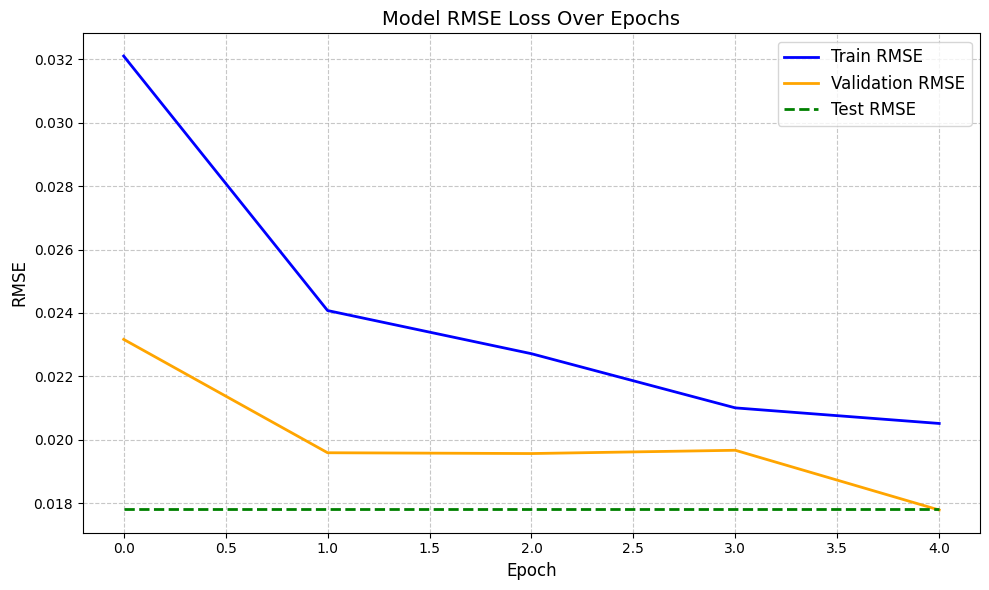

Saved predictions plot to: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_predictions_vs_actual.png


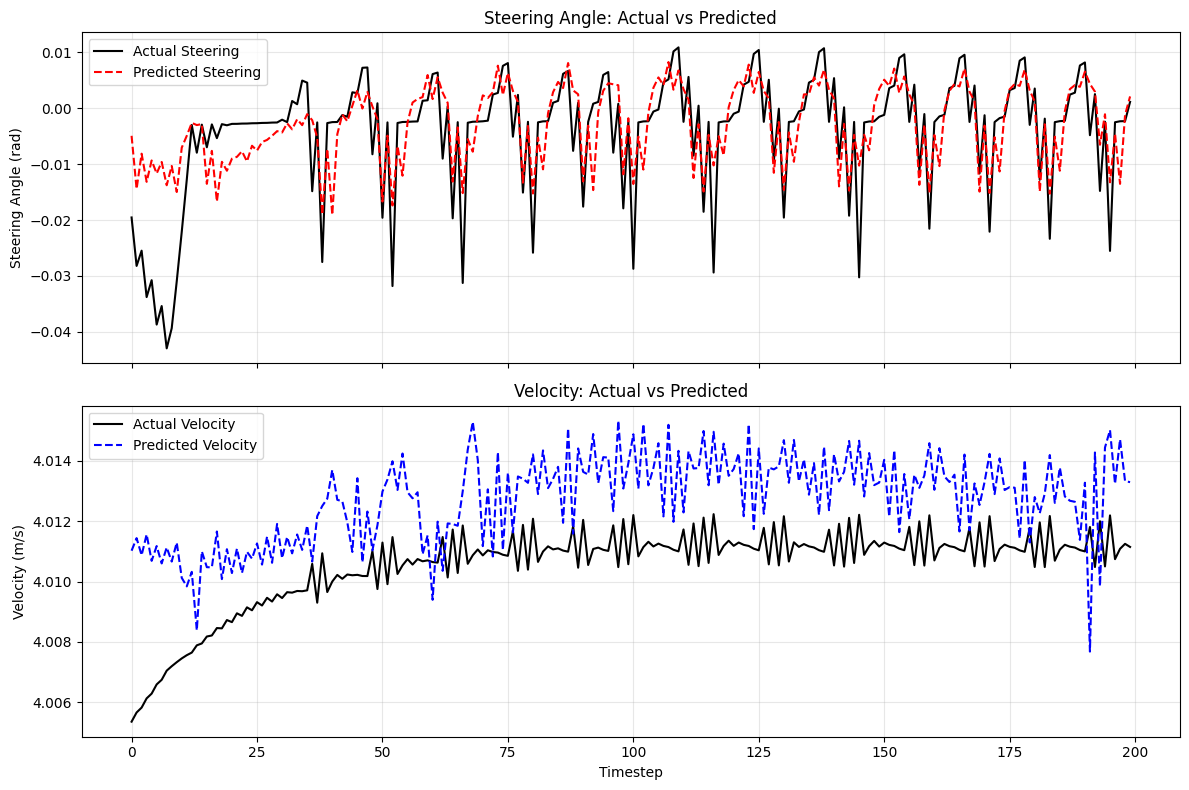

In [ ]:
# Example Execution:
analytics_dir = os.path.join(os.getcwd(), "..", "models", SAVE_MODEL_NAME, datetime.now().strftime("%Y%m%d"))
plot_learning_curves(history, model_name=SAVE_MODEL_NAME, save_dir=analytics_dir)
plot_predictions_vs_actual(
    model,
    test_loader,
    DEVICE,
    target_scaler=fitted_target_scaler,
    num_samples=200,
    model_name=SAVE_MODEL_NAME,
    save_dir=analytics_dir,
)

Saved episode prediction plot to: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_episode_0_predictions_vs_actual.png


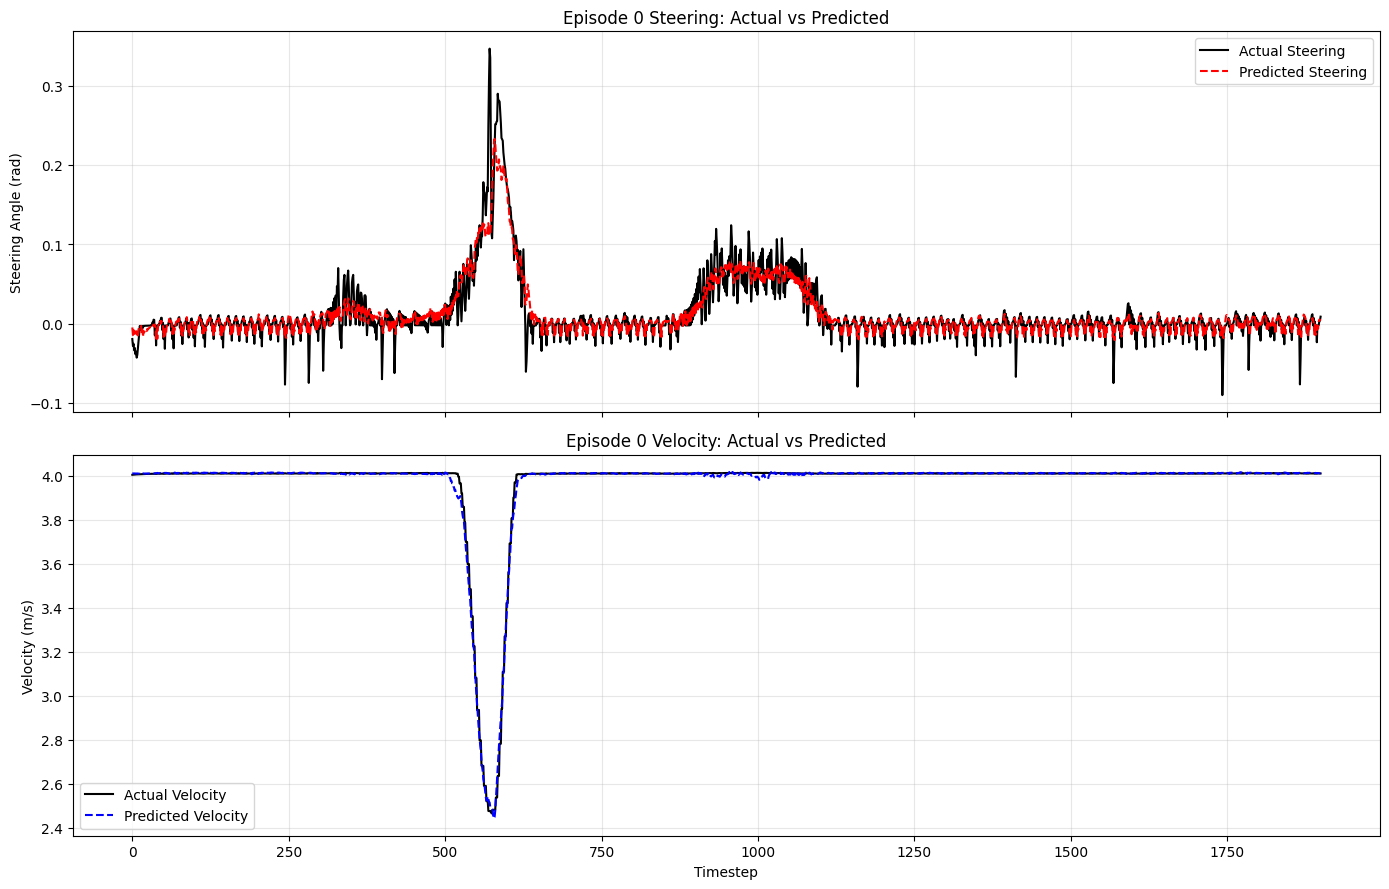

In [ ]:
plot_test_episode_predictions(
    model,
    test_episodes,
    episode_index=0,
    seq_length=SEQ_LENGTH,
    predict_length=PREDICT_LENGTH,
    device=DEVICE,
    target_scaler=fitted_target_scaler,
    model_name=SAVE_MODEL_NAME,
    save_dir=analytics_dir,
    max_sequence_length=2000,  # Set to limit visualization (e.g., 4000 to show only first 4k timesteps)
)

In [ ]:
# Diagnostic: quantify label distribution + naive baselines to explain low loss vs poor steering generalization

from sklearn.metrics import mean_squared_error


def _collect_window_targets(episodes, seq_length, predict_length):
    ys = []
    for ep in episodes:
        T = ep["targets"].shape[0]
        max_start = T - seq_length - predict_length + 1
        if max_start <= 0:
            continue
        for start in range(max_start):
            target_idx = start + seq_length + predict_length - 1
            ys.append(ep["targets"][target_idx])
    return np.array(ys)


def diagnose_targets_and_baselines(pkl_path, seq_length=100, predict_length=1, seed=42):
    with open(pkl_path, "rb") as f:
        episodes = pickle.load(f)

    episodes = [ep for ep in episodes if not ep.get("has_collision", False)]

    # split exactly like training pipeline
    idx = list(range(len(episodes)))
    random.seed(seed)
    random.shuffle(idx)
    episodes = [episodes[i] for i in idx]

    n = len(episodes)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_eps = episodes[:n_train]
    test_eps = episodes[n_train + n_val :]

    # raw target distribution
    all_targets = np.concatenate([ep["targets"] for ep in episodes], axis=0)
    steering = all_targets[:, 0]
    velocity = all_targets[:, 1]

    print("=== Raw target distribution ===")
    print(f"steering mean={steering.mean():.6f}, std={steering.std():.6f}, min={steering.min():.6f}, max={steering.max():.6f}")
    print(f"velocity mean={velocity.mean():.6f}, std={velocity.std():.6f}, min={velocity.min():.6f}, max={velocity.max():.6f}")
    for th in [0.005, 0.01, 0.02, 0.05]:
        frac = (np.abs(steering) < th).mean()
        print(f"fraction |steering| < {th:.3f}: {frac:.3f}")

    # fit target scaler on train only (same as pipeline)
    target_scaler = MinMaxScaler()
    train_targets_flat = np.concatenate([ep["targets"] for ep in train_eps], axis=0)
    target_scaler.fit(train_targets_flat)

    # scale targets for baseline comparison in training space
    for ep in train_eps:
        ep["targets_scaled"] = target_scaler.transform(ep["targets"])
    for ep in test_eps:
        ep["targets_scaled"] = target_scaler.transform(ep["targets"])

    def collect_scaled_window_targets(eps):
        ys = []
        for ep in eps:
            T = ep["targets_scaled"].shape[0]
            max_start = T - seq_length - predict_length + 1
            if max_start <= 0:
                continue
            for s in range(max_start):
                t = s + seq_length + predict_length - 1
                ys.append(ep["targets_scaled"][t])
        return np.array(ys)

    y_train = collect_scaled_window_targets(train_eps)
    y_test = collect_scaled_window_targets(test_eps)

    # trivial baselines
    pred_mean = np.repeat(y_train.mean(axis=0, keepdims=True), len(y_test), axis=0)
    pred_zero = np.zeros_like(y_test)

    rmse_mean_scaled = np.sqrt(np.mean((pred_mean - y_test) ** 2, axis=0))
    rmse_zero_scaled = np.sqrt(np.mean((pred_zero - y_test) ** 2, axis=0))

    print("\n=== Trivial baseline RMSE in scaled space [steering, velocity] ===")
    print(f"predict train-mean: {rmse_mean_scaled}")
    print(f"predict all-zeros : {rmse_zero_scaled}")

    # and in physical units
    y_test_phys = target_scaler.inverse_transform(y_test)
    mean_phys = target_scaler.inverse_transform(pred_mean)
    zero_phys = target_scaler.inverse_transform(pred_zero)

    rmse_mean_phys = np.sqrt(np.mean((mean_phys - y_test_phys) ** 2, axis=0))
    rmse_zero_phys = np.sqrt(np.mean((zero_phys - y_test_phys) ** 2, axis=0))

    print("\n=== Trivial baseline RMSE in physical units [steering(rad), velocity(m/s)] ===")
    print(f"predict train-mean: {rmse_mean_phys}")
    print(f"predict all-zeros : {rmse_zero_phys}")


# Run diagnostic
diagnose_targets_and_baselines(PKL_PATH, seq_length=SEQ_LENGTH, predict_length=PREDICT_LENGTH, seed=42)

=== Raw target distribution ===
steering mean=-0.000374, std=0.050936, min=-0.400000, max=0.400000
velocity mean=3.928407, std=0.304506, min=2.000000, max=12.000000
fraction |steering| < 0.005: 0.435
fraction |steering| < 0.010: 0.571
fraction |steering| < 0.020: 0.687
fraction |steering| < 0.050: 0.846

=== Trivial baseline RMSE in scaled space [steering, velocity] ===
predict train-mean: [0.06546752 0.03055692]
predict all-zeros : [0.50378174 0.19533119]

=== Trivial baseline RMSE in physical units [steering(rad), velocity(m/s)] ===
predict train-mean: [0.05237215 0.30581918]
predict all-zeros : [0.4030205 1.9533734]


In [ ]:
# Diagnostic: model behavior by target (not just aggregate loss)

def evaluate_per_target_metrics(model, dataloader, device, target_scaler):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            out = model(batch_x).cpu().numpy()
            preds.append(out)
            actuals.append(batch_y.numpy())

    preds = np.concatenate(preds, axis=0)
    actuals = np.concatenate(actuals, axis=0)

    # back to physical units
    preds_phys = target_scaler.inverse_transform(preds)
    actuals_phys = target_scaler.inverse_transform(actuals)

    # metrics per target
    names = ["steering(rad)", "velocity(m/s)"]
    print("=== Model architecture sanity check ===")
    print(f"model.model_type stored: {model.model_type}")
    if model.model_type not in ["LSTM", "GRU", "RNN"]:
        print("WARNING: model_type is not one of [LSTM, GRU, RNN]. In this class that falls back to plain RNN.")

    print("\n=== Per-target metrics in physical units ===")
    for i, name in enumerate(names):
        y = actuals_phys[:, i]
        yhat = preds_phys[:, i]
        rmse = np.sqrt(np.mean((yhat - y) ** 2))
        mae = np.mean(np.abs(yhat - y))
        var_y = np.var(y)
        r2 = 1.0 - (np.mean((yhat - y) ** 2) / (var_y + 1e-12))
        print(f"{name}: RMSE={rmse:.6f}, MAE={mae:.6f}, R2={r2:.6f}, pred_std={np.std(yhat):.6f}, true_std={np.std(y):.6f}")

    print("\n=== Collapse check ===")
    steer_pred_std = np.std(preds_phys[:, 0])
    steer_true_std = np.std(actuals_phys[:, 0])
    vel_pred_std = np.std(preds_phys[:, 1])
    vel_true_std = np.std(actuals_phys[:, 1])
    print(f"steering std ratio pred/true: {steer_pred_std / (steer_true_std + 1e-12):.4f}")
    print(f"velocity std ratio pred/true: {vel_pred_std / (vel_true_std + 1e-12):.4f}")


evaluate_per_target_metrics(model, test_loader, DEVICE, fitted_target_scaler)

=== Model architecture sanity check ===
model.model_type stored: LSTM

=== Per-target metrics in physical units ===
steering(rad): RMSE=0.019645, MAE=0.009664, R2=0.839988, pred_std=0.045740, true_std=0.049109
velocity(m/s): RMSE=0.047184, MAE=0.009978, R2=0.973585, pred_std=0.299537, true_std=0.290319

=== Collapse check ===
steering std ratio pred/true: 0.9314
velocity std ratio pred/true: 1.0318


In [ ]:
#currently non functional, need to rework as needed to actually output sequences

# def analyze_prediction_horizon_accuracy(model, test_episodes, seq_length, device, target_scaler, max_horizon=None, sample_size=None):
#     """
#     Analyze how prediction accuracy degrades as we predict further into the future.
    
#     For each test episode, creates windows of length seq_length and evaluates the model
#     at different prediction horizons (1, 2, 3, ... steps ahead from the end of the sequence).
    
#     Args:
#         max_horizon: Maximum number of steps ahead to evaluate (default: try up to episode length)
#         sample_size: Limit number of windows to evaluate (default: use all)
    
#     Returns:
#         horizons: list of prediction distances (1, 2, 3, ...)
#         steering_rmse_list: RMSE for steering at each horizon
#         velocity_rmse_list: RMSE for velocity at each horizon
#     """
#     model.eval()
    
#     horizons = []
#     predictions_by_horizon = {h: [] for h in range(1, 100)}  # Support up to 100 steps ahead
#     actuals_by_horizon = {h: [] for h in range(1, 100)}
    
#     with torch.no_grad():
#         for ep_idx, ep in enumerate(test_episodes):
#             inputs = ep["inputs"]
#             targets = ep["targets"]
#             T = inputs.shape[0]
            
#             # Determine max horizon for this episode
#             episode_max_horizon = T - seq_length
#             if max_horizon is not None:
#                 episode_max_horizon = min(episode_max_horizon, max_horizon)
            
#             if episode_max_horizon <= 0:
#                 continue
            
#             # Create windows and evaluate at different horizons
#             max_start = T - seq_length - episode_max_horizon
#             window_count = 0
            
#             for start in range(max_start):
#                 # Get input window
#                 window = inputs[start : start + seq_length]
#                 window_t = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(device)
                
#                 # Get model prediction (trained at PREDICT_LENGTH horizon)
#                 pred = model(window_t).cpu().numpy()[0]  # (2,)
                
#                 # Evaluate this prediction at different actual horizons in the episode
#                 for horizon in range(1, episode_max_horizon + 1):
#                     target_idx = start + seq_length + horizon - 1
#                     if target_idx < T:
#                         actual = targets[target_idx]
                        
#                         # Store for this horizon
#                         if horizon <= 50:  # Limit to reasonable horizon
#                             predictions_by_horizon[horizon].append(pred)
#                             actuals_by_horizon[horizon].append(actual)
                
#                 window_count += 1
#                 if sample_size is not None and window_count >= sample_size:
#                     break
    
#     # Calculate RMSE at each horizon
#     horizons = []
#     steering_rmse_list = []
#     velocity_rmse_list = []
#     combined_rmse_list = []
    
#     for horizon in sorted([h for h in predictions_by_horizon.keys() if len(predictions_by_horizon[h]) > 0]):
#         preds = np.array(predictions_by_horizon[horizon])
#         actuals = np.array(actuals_by_horizon[horizon])
        
#         # Inverse transform if scaler provided
#         if target_scaler is not None:
#             preds = target_scaler.inverse_transform(preds)
#             actuals = target_scaler.inverse_transform(actuals)
        
#         # Calculate per-dimension RMSE
#         steer_rmse = np.sqrt(np.mean((preds[:, 0] - actuals[:, 0]) ** 2))
#         vel_rmse = np.sqrt(np.mean((preds[:, 1] - actuals[:, 1]) ** 2))
#         combined_rmse = np.sqrt(np.mean((preds - actuals) ** 2))
        
#         horizons.append(horizon)
#         steering_rmse_list.append(steer_rmse)
#         velocity_rmse_list.append(vel_rmse)
#         combined_rmse_list.append(combined_rmse)
    
#     # Plot results
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # Per-target RMSE
#     axes[0].plot(horizons, steering_rmse_list, marker='o', label='Steering', linewidth=2, markersize=6)
#     axes[0].plot(horizons, velocity_rmse_list, marker='s', label='Velocity', linewidth=2, markersize=6)
#     axes[0].set_xlabel('Prediction Horizon (steps ahead)', fontsize=12)
#     axes[0].set_ylabel('RMSE (physical units)', fontsize=12)
#     axes[0].set_title('Per-Target RMSE vs Prediction Horizon', fontsize=13)
#     axes[0].legend(fontsize=11)
#     axes[0].grid(True, alpha=0.3)
    
#     # Combined RMSE
#     axes[1].plot(horizons, combined_rmse_list, marker='d', color='purple', linewidth=2, markersize=6)
#     axes[1].set_xlabel('Prediction Horizon (steps ahead)', fontsize=12)
#     axes[1].set_ylabel('Combined RMSE (physical units)', fontsize=12)
#     axes[1].set_title('Combined RMSE vs Prediction Horizon', fontsize=13)
#     axes[1].grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print summary table
#     print("\n=== Horizon vs Prediction Accuracy ===")
#     print(f"{'Horizon':>8} {'Steering RMSE':>16} {'Velocity RMSE':>16} {'Combined RMSE':>16}")
#     print("-" * 58)
#     for h, s_rmse, v_rmse, c_rmse in zip(horizons, steering_rmse_list, velocity_rmse_list, combined_rmse_list):
#         print(f"{h:>8d} {s_rmse:>16.6f} {v_rmse:>16.6f} {c_rmse:>16.6f}")
    
#     return horizons, steering_rmse_list, velocity_rmse_list, combined_rmse_list


# # Run analysis on test episodes with a reasonable sample size to avoid long computation
# print("Analyzing prediction accuracy at different future horizons...")
# horizons, steer_rmse, vel_rmse, combined_rmse = analyze_prediction_horizon_accuracy(
#     model, 
#     test_episodes, 
#     seq_length=SEQ_LENGTH, 
#     device=DEVICE,
#     target_scaler=fitted_target_scaler,
#     max_horizon=50,  # Evaluate up to 50 steps ahead
#     sample_size=100  # Use up to 100 windows per episode to limit computation
# )


## Section 6: Model Saving

Save model as a .pkl file or to hugging face or something if good!

Could also allow for future tuning and training

In [ ]:
import joblib
import re
import inspect

def evaluate_regression_metrics(model, dataloader, device, target_scaler):
    """
    Compute RMSE and R2 for steering and velocity in physical units.
    Returns a metrics dictionary for reporting/saving.
    """
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            out = model(batch_x).cpu().numpy()
            preds.append(out)
            actuals.append(batch_y.numpy())

    preds = np.concatenate(preds, axis=0)
    actuals = np.concatenate(actuals, axis=0)

    preds_phys = target_scaler.inverse_transform(preds)
    actuals_phys = target_scaler.inverse_transform(actuals)

    steering_rmse = float(np.sqrt(np.mean((preds_phys[:, 0] - actuals_phys[:, 0]) ** 2)))
    velocity_rmse = float(np.sqrt(np.mean((preds_phys[:, 1] - actuals_phys[:, 1]) ** 2)))
    steering_r2 = float(r2_score(actuals_phys[:, 0], preds_phys[:, 0]))
    velocity_r2 = float(r2_score(actuals_phys[:, 1], preds_phys[:, 1]))

    return {
        "steering_rmse": steering_rmse,
        "velocity_rmse": velocity_rmse,
        "steering_r2": steering_r2,
        "velocity_r2": velocity_r2,
        "r2_mean": float((steering_r2 + velocity_r2) / 2.0),
    }

def estimate_model_gflops_and_latency(model, seq_length, batch_size=1, jetson_peak_gflops=472.0, available_fraction=0.35):
    """
    Rough FLOPs + latency estimate for one forward pass.
    Assumes Jetson Nano peak ~472 GFLOPS (FP16) and only a fraction is available
    while RViz/localization/other nodes run concurrently.
    """
    cfg = getattr(model, "save_config", {})
    model_type = cfg.get("model_type", "LSTM").upper()
    num_layers = int(cfg.get("num_rnn_layers", 1))
    hidden_dim = int(cfg.get("rnn_hidden_dim", 1))
    input_dim = int(cfg.get("embedding_dim", cfg.get("input_dim", 1))) if cfg.get("use_embedding", False) else int(cfg.get("input_dim", 1))
    fc_sizes = list(cfg.get("fc_layer_sizes", []))
    output_dim = int(cfg.get("output_dim", 2))

    if model_type == "LSTM":
        gates = 4
    elif model_type == "GRU":
        gates = 3
    else:
        gates = 1

    # MACs per gate: input->hidden + hidden->hidden; FLOPs approx 2 * MACs
    rnn_flops = 0.0
    layer_input_dim = input_dim
    for _ in range(num_layers):
        macs_per_timestep = gates * (layer_input_dim * hidden_dim + hidden_dim * hidden_dim)
        flops_per_timestep = 2.0 * macs_per_timestep
        rnn_flops += flops_per_timestep * seq_length * batch_size
        layer_input_dim = hidden_dim

    # FC head FLOPs
    fc_dims = [hidden_dim] + fc_sizes + [output_dim]
    fc_flops = 0.0
    for i in range(len(fc_dims) - 1):
        fc_flops += 2.0 * fc_dims[i] * fc_dims[i + 1] * batch_size

    total_flops = rnn_flops + fc_flops
    total_gflops = total_flops / 1e9

    effective_gflops = jetson_peak_gflops * available_fraction
    latency_seconds = total_gflops / max(effective_gflops, 1e-9)

    return {
        "jetson_peak_gflops": float(jetson_peak_gflops),
        "assumed_available_fraction": float(available_fraction),
        "effective_available_gflops": float(effective_gflops),
        "estimated_inference_gflops": float(total_gflops),
        "estimated_latency_ms": float(latency_seconds * 1000.0),
        "batch_size_for_estimate": int(batch_size),
        "seq_length_for_estimate": int(seq_length),
    }

def save_model_and_artifacts(
    model,
    input_scaler,
    target_scaler,
    history,
    test_loader,
    device,
    model_name="f1tenth_model",
    save_config=None,
    seq_length_for_latency=100,
    jetson_available_fraction=0.35,
):
    """
    Saves model bundle:
    - model weights (.pt)
    - model/scaler config and metadata (.json)
    - scalers (.pkl)
    - metrics summary (.json)
    """
    sanitized_model_name = re.sub(r'[\\/*?:"<>|]', "_", model_name)
    run_date = datetime.now().strftime("%Y%m%d")

    models_dir = os.path.join(os.getcwd(), "..", "models")
    os.makedirs(models_dir, exist_ok=True)
    model_run_dir = os.path.join(models_dir, sanitized_model_name, run_date)
    os.makedirs(model_run_dir, exist_ok=True)

    model_save_path = os.path.join(model_run_dir, f"{sanitized_model_name}.pt")
    input_scaler_path = os.path.join(model_run_dir, f"{sanitized_model_name}_input_scaler.pkl")
    target_scaler_path = os.path.join(model_run_dir, f"{sanitized_model_name}_target_scaler.pkl")
    config_path = os.path.join(model_run_dir, f"{sanitized_model_name}_config.json")
    metrics_json_path = os.path.join(model_run_dir, f"{sanitized_model_name}_metrics_summary.json")

    torch.save(model.state_dict(), model_save_path)
    joblib.dump(input_scaler, input_scaler_path)
    joblib.dump(target_scaler, target_scaler_path)

    param_count = int(sum(p.numel() for p in model.parameters()))
    regression_metrics = evaluate_regression_metrics(model, test_loader, device, target_scaler)
    latency_metrics = estimate_model_gflops_and_latency(
        model=model,
        seq_length=seq_length_for_latency,
        batch_size=1,
        available_fraction=jetson_available_fraction,
    )

    test_rmse_series = history.get("test_rmse", [])
    test_rmse_value = float(test_rmse_series[-1]) if len(test_rmse_series) > 0 else float("nan")

    metrics_summary = {
        "param_count": param_count,
        "final_train_rmse": float(history["train_rmse"][-1]) if history.get("train_rmse") else None,
        "final_val_rmse": float(history["val_rmse"][-1]) if history.get("val_rmse") else None,
        "final_test_rmse": test_rmse_value,
        "mean_epoch_time_sec": float(np.mean(history["epoch_time_sec"])) if history.get("epoch_time_sec") else None,
        "steering_rmse": regression_metrics["steering_rmse"],
        "velocity_rmse": regression_metrics["velocity_rmse"],
        "steering_r2": regression_metrics["steering_r2"],
        "velocity_r2": regression_metrics["velocity_r2"],
        "r2_mean": regression_metrics["r2_mean"],
        "latency_estimate": latency_metrics,
    }

    with open(metrics_json_path, "w") as f:
        json.dump(metrics_summary, f, indent=2)

    config_payload = {
        "class_name": "F1TenthSequenceModel",
        "artifact_dir": model_run_dir,
        "state_dict_file": os.path.basename(model_save_path),
        "input_scaler_file": os.path.basename(input_scaler_path),
        "target_scaler_file": os.path.basename(target_scaler_path),
        "metrics_summary_file": os.path.basename(metrics_json_path),
        "model_config": save_config if save_config is not None else {},
    }
    with open(config_path, "w") as f:
        json.dump(config_payload, f, indent=2)

    print(f"Artifact directory: {model_run_dir}")
    print(f"Model weights saved: {model_save_path}")
    print(f"Input scaler saved: {input_scaler_path}")
    print(f"Target scaler saved: {target_scaler_path}")
    print(f"Model config saved: {config_path}")
    print(f"Metrics summary saved: {metrics_json_path}")
    print("Latency estimate:")
    print(latency_metrics)

    return {
        "artifact_dir": model_run_dir,
        "model_path": model_save_path,
        "input_scaler_path": input_scaler_path,
        "target_scaler_path": target_scaler_path,
        "config_path": config_path,
        "metrics_json_path": metrics_json_path,
        "metrics_summary": metrics_summary,
        "latency_metrics": latency_metrics,
    }

def load_model_bundle(model_name="f1tenth_model", device=DEVICE):
    """
    Loads saved bundle using config JSON and returns model + scalers + metadata.
    """
    sanitized_model_name = re.sub(r'[\\/*?:"<>|]', "_", model_name)
    models_dir = os.path.join(os.getcwd(), "..", "models")
    model_base_dir = os.path.join(models_dir, sanitized_model_name)
    if not os.path.isdir(model_base_dir):
        raise FileNotFoundError(f"No saved model directory found for {sanitized_model_name} at {model_base_dir}")

    run_dirs = sorted([d for d in os.listdir(model_base_dir) if os.path.isdir(os.path.join(model_base_dir, d))])
    if not run_dirs:
        raise FileNotFoundError(f"No dated run directories found in {model_base_dir}")

    selected_run_dir = os.path.join(model_base_dir, run_dirs[-1])
    config_path = os.path.join(selected_run_dir, f"{sanitized_model_name}_config.json")

    with open(config_path, "r") as f:
        cfg = json.load(f)

    model_cfg = cfg["model_config"]
    loaded_model = F1TenthSequenceModel(**model_cfg).to(device)

    state_dict_path = os.path.join(selected_run_dir, cfg["state_dict_file"])
    loaded_model.load_state_dict(torch.load(state_dict_path, map_location=device))
    loaded_model.eval()

    loaded_input_scaler = joblib.load(os.path.join(selected_run_dir, cfg["input_scaler_file"]))
    loaded_target_scaler = joblib.load(os.path.join(selected_run_dir, cfg["target_scaler_file"]))

    return loaded_model, loaded_input_scaler, loaded_target_scaler, cfg


In [ ]:
# Example Execution:
MODEL_NAME = SAVE_MODEL_NAME

save_outputs = save_model_and_artifacts(
    model=model,
    input_scaler=fitted_input_scaler,
    target_scaler=fitted_target_scaler,
    history=history,
    test_loader=test_loader,
    device=DEVICE,
    model_name=MODEL_NAME,
    save_config=MODEL_CONFIG,
    seq_length_for_latency=SEQ_LENGTH,
    jetson_available_fraction=0.35,  # Assumes 35% of Nano compute available while other ROS tasks run
)

print("\nSaved metrics summary:")
print(json.dumps(save_outputs["metrics_summary"], indent=2))


Artifact directory: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416
Model weights saved: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1.pt
Input scaler saved: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_input_scaler.pkl
Target scaler saved: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_target_scaler.pkl
Model config saved: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_config.json
Metrics summary saved: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/notebooks/../models/LSTM_1B_32D_Pred_1/20260416/LSTM_1B_32D_Pred_1_metrics_summary.json
Latency estimate:
{'jetson_peak_gflops': 472.0, 'assumed_available_fraction': 0.35, 'effect

## Section 7: Load Saved Model and Test

Load model bundle artifacts after saving and verify performance on the same test loader.

This is useful for deployment sanity checks and presentation demos.

In [ ]:
loaded_model, loaded_input_scaler, loaded_target_scaler, loaded_cfg = load_model_bundle(
    model_name=MODEL_NAME,
    device=DEVICE,
)

reloaded_test_rmse = evaluate_model(loaded_model, test_loader, criterion, DEVICE)
reloaded_regression_metrics = evaluate_regression_metrics(
    loaded_model,
    test_loader,
    DEVICE,
    loaded_target_scaler,
)

print(f"Reloaded model test RMSE: {reloaded_test_rmse:.8f}")
print("Reloaded model metrics:")
print(json.dumps(reloaded_regression_metrics, indent=2))
print("Loaded config model type:", loaded_cfg["model_config"]["model_type"])

Reloaded model test RMSE: 0.01781377
Reloaded model metrics:
{
  "steering_rmse": 0.019644537940621376,
  "velocity_rmse": 0.04718419164419174,
  "steering_r2": 0.8399876952171326,
  "velocity_r2": 0.9735854864120483,
  "r2_mean": 0.9067865908145905
}
Loaded config model type: LSTM
